# Exploratory Analysis of PoQeMoN QoE dataset


https://github.com/Lamyne/Poqemon-QoE-Dataset/tree/master

In [ ]:
!pip install lux-api --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.0/127.0 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
import lux
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import output
output.enable_custom_widget_manager()


url = "https://github.com/rodrigodg1/privacy-qoe-system/raw/main/fhevm/poqemon.csv"  # Replace with your actual URL
df = pd.read_csv(url)
df.default_display = "lux"

# Calculate summary statistics
#summary_stats = df.describe()
#summary_stats

df

## Exploratory Analysis

In [ ]:
!pip install seaborn

<ipython-input-27-8d9e56556eb7>:26: FutureWarning:

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<ipython-input-27-8d9e56556eb7>:32: UserWarning:Ignoring `palette` because no `hue` variable has been assigned.
<ipython-input-27-8d9e56556eb7>:38: FutureWarning:

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



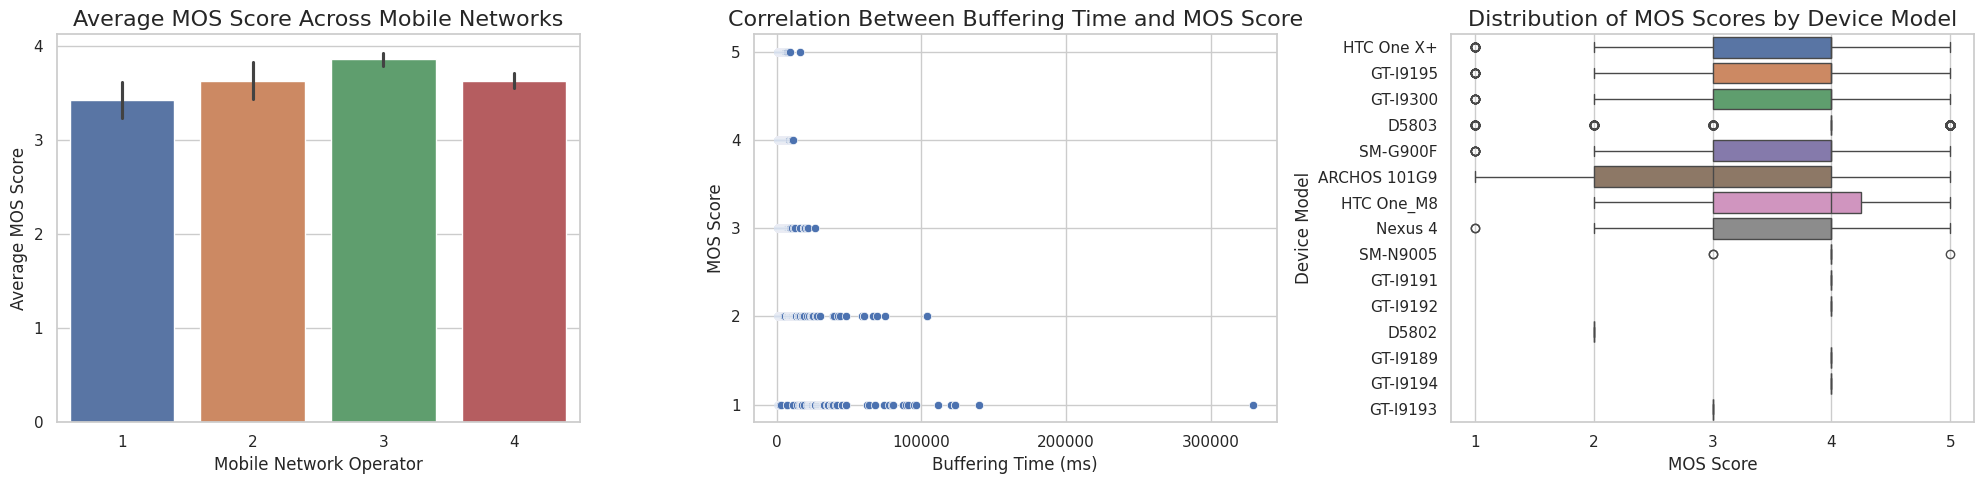

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dataset is your DataFrame
dataset = df

# Set seaborn style and apply the color palette
sns.set(style="whitegrid")
operator_palette = sns.color_palette("deep", len(dataset['QoS_operator'].unique()))  # Create a palette with unique colors
device_palette = sns.color_palette("deep", len(dataset['QoD_model'].unique()))  # Create a palette with unique colors for devices
buffering_palette = sns.color_palette("deep", len(dataset['QoD_model'].unique()))  # Create a palette with unique colors for devices

# Create a 1x3 grid for the plots with increased figure size
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Increase font sizes for all elements
font_size = 16
plt.rc('axes', titlesize=font_size)      # Title size
plt.rc('axes', labelsize=font_size)      # X and Y label size
plt.rc('xtick', labelsize=font_size)     # X tick label size
plt.rc('ytick', labelsize=font_size)     # Y tick label size
plt.rc('legend', fontsize=font_size)     # Legend font size

# 1. MOS Distribution Across Mobile Networks with distinct colors for each operator
sns.barplot(data=dataset, x='QoS_operator', y='MOS', dodge=False, ax=axes[0], palette=operator_palette)
axes[0].set_title('Average MOS Score Across Mobile Networks')
axes[0].set_xlabel('Mobile Network Operator')
axes[0].set_ylabel('Average MOS Score')

# 2. Buffering Events and MOS Correlation with different colors based on a category
sns.scatterplot(data=dataset, x='QoA_BUFFERINGtime', y='MOS', palette=buffering_palette, ax=axes[1])
axes[1].set_title('Correlation Between Buffering Time and MOS Score')
axes[1].set_xlabel('Buffering Time (ms)')
axes[1].set_ylabel('MOS Score')

# 3. Distribution of MOS Scores by Device Model (Horizontal Box Plot for better readability)
sns.boxplot(data=dataset, y='QoD_model', x='MOS', ax=axes[2], palette=device_palette)  # Switch x and y for horizontal plot
axes[2].set_title('Distribution of MOS Scores by Device Model')
axes[2].set_xlabel('MOS Score')
axes[2].set_ylabel('Device Model')

# Adjust layout for better viewing
plt.tight_layout()

# Save the figure as a PDF
plt.savefig("MOS_analysis.pdf", format='pdf')

plt.show()



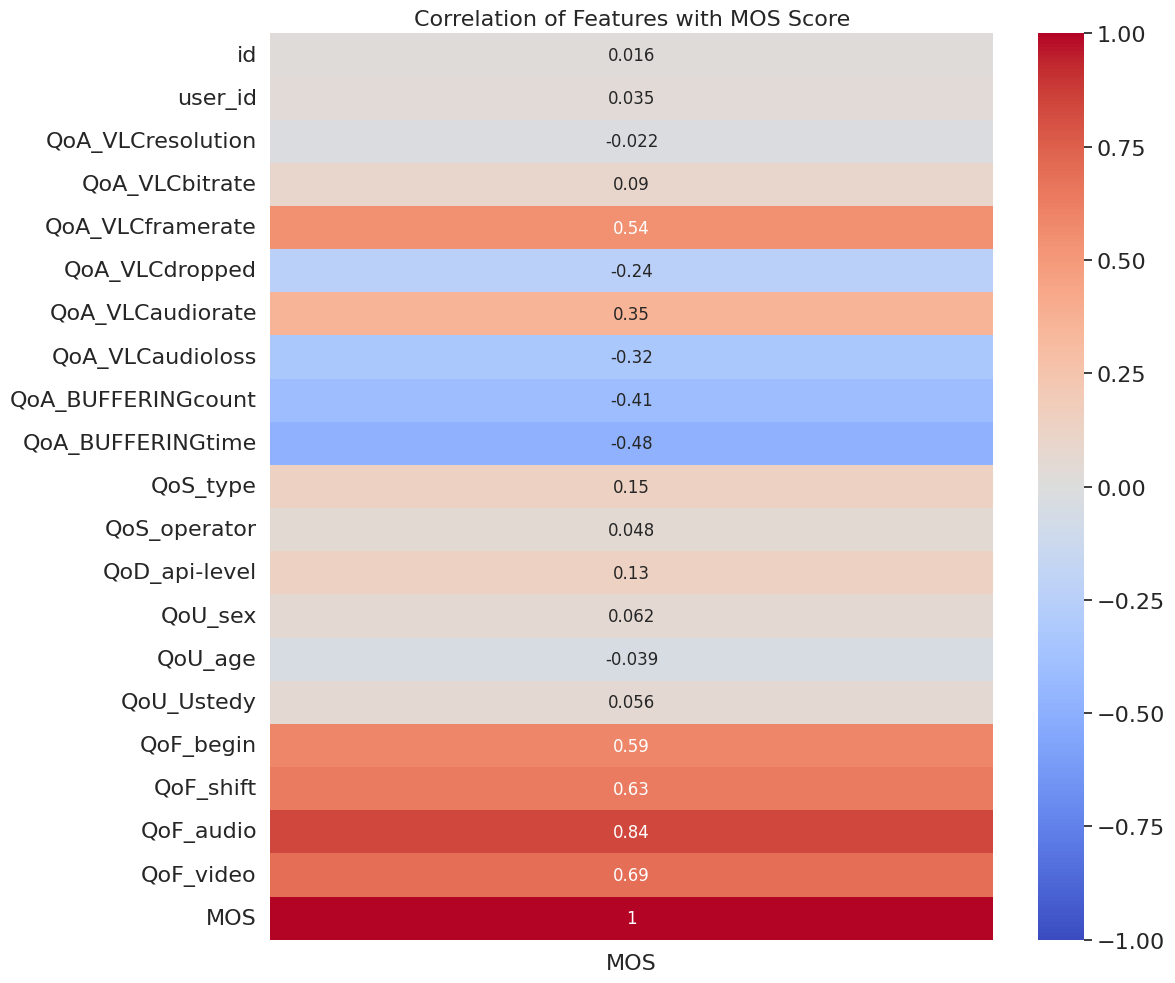

Correlation with MOS:
MOS                   1.000000
QoF_audio             0.840735
QoF_video             0.689358
QoF_shift             0.634058
QoF_begin             0.591324
QoA_VLCframerate      0.544164
QoA_VLCaudiorate      0.353631
QoS_type              0.146741
QoD_api-level         0.133560
QoA_VLCbitrate        0.089671
QoU_sex               0.062251
QoU_Ustedy            0.055831
QoS_operator          0.048154
user_id               0.035284
id                    0.016395
QoA_VLCresolution    -0.022485
QoU_age              -0.039230
QoA_VLCdropped       -0.237135
QoA_VLCaudioloss     -0.323338
QoA_BUFFERINGcount   -0.411176
QoA_BUFFERINGtime    -0.482378
Name: MOS, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation analysis
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix[['MOS']], annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation of Features with MOS Score')
plt.tight_layout()
plt.show()

# Print the correlation values with MOS
mos_correlation = correlation_matrix['MOS'].sort_values(ascending=False)
print("Correlation with MOS:")
print(mos_correlation)

## MOS DATA

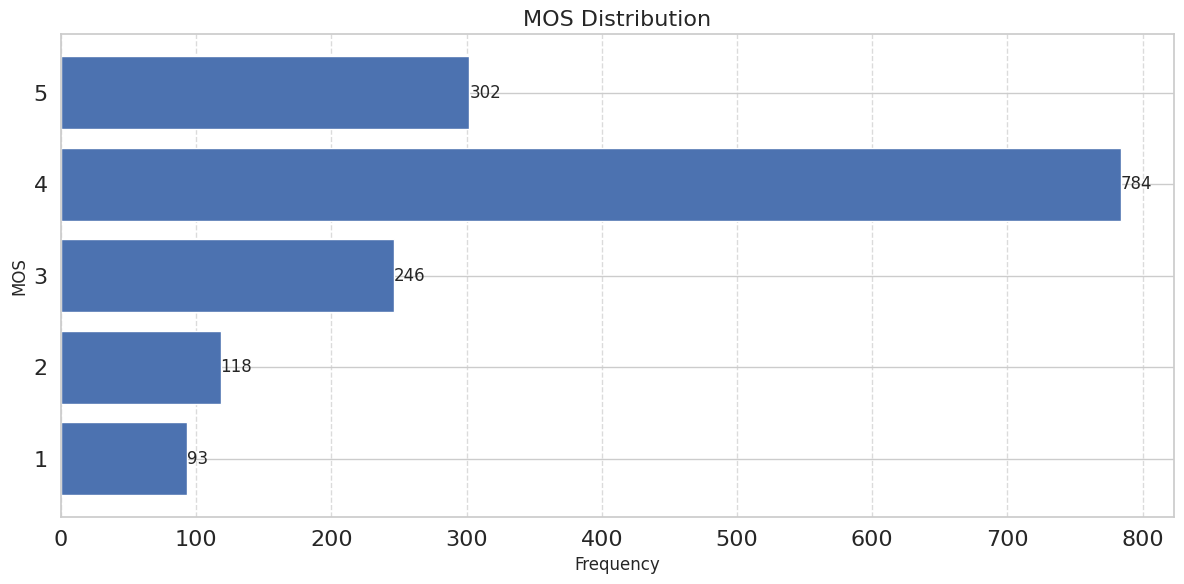

MOS Distribution:
MOS
1     93
2    118
3    246
4    784
5    302
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV data
data = df

# Calculate MOS distribution
mos_distribution = data['MOS'].value_counts().sort_index()

# Create the MOS distribution plot
plt.figure(figsize=(12, 6))  # Adjusted figure size for horizontal layout
bars = plt.barh(mos_distribution.index, mos_distribution.values)
plt.title('MOS Distribution', fontsize=16)
plt.ylabel('MOS', fontsize=12)
plt.xlabel('Frequency', fontsize=12)
plt.yticks(range(1, 6))  # Assuming MOS values are from 1 to 5

# Add value labels to the right of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width}',
             ha='left', va='center')

# Customize the plot
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
#plt.savefig('mos_distribution.pdf',  format='pdf')
plt.show()

# Print MOS distribution
print("MOS Distribution:")
print(mos_distribution)



In [ ]:
# Extract the 'MOS' column
mos_data = data['MOS']

# Perform statistical analysis on the 'MOS' data
mos_stats = mos_data.describe()

# Additional statistical metrics
mos_mode = mos_data.mode().iloc[0]  # Mode might return multiple values; take the first one
mos_median = mos_data.median()
mos_std = mos_data.std()

mos_stats_results = {
    "count": mos_stats['count'],
    "mean": mos_stats['mean'],
    "std": mos_std,
    "min": mos_stats['min'],
    "25%": mos_stats['25%'],
    "50% (median)": mos_median,
    "75%": mos_stats['75%'],
    "max": mos_stats['max'],
    "mode": mos_mode
}

mos_stats_results


{'count': 1543.0,
 'mean': 3.7025275437459495,
 'std': 1.0562825886052112,
 'min': 1.0,
 '25%': 3.0,
 '50% (median)': 4.0,
 '75%': 4.0,
 'max': 5.0,
 'mode': 4}

In [ ]:
mos_distribution = data['MOS'].value_counts().sort_index()

mos_distribution

/usr/local/lib/python3.10/dist-packages/lux/executor/PandasExecutor.py:567: UserWarning:Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
mos_distribution = data['MOS'].value_counts().sum()
mos_distribution

1543

## Encoding (categorization)


## Sensitive Columns

## Columns to encode

In [ ]:
df[["QoD_model", "QoD_os-version"]]

/usr/local/lib/python3.10/dist-packages/lux/executor/PandasExecutor.py:548: UserWarning:Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/usr/local/lib/python3.10/dist-packages/lux/executor/PandasExecutor.py:548: UserWarning:Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/usr/local/lib/python3.10/dist-packages/altair/utils/core.py:384: FutureWarning:the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
/usr/local/lib/python3.10/dist-packages/altair/utils/core.py:384: FutureWarning:the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Select the columns to encode
columns_to_encode = ["QoD_model", "QoD_os-version"]

# Initialize label encoders
label_encoders = {col: LabelEncoder() for col in columns_to_encode}

# Apply label encoding to the specified columns
for col in columns_to_encode:
    if col in df.columns:
        # Fit the encoder and transform the column
        encoded_values = label_encoders[col].fit_transform(df[col])
        # Add 1 to shift the encoding to start from 1 instead of 0
        df[col] = encoded_values + 1

# Save the encoded dataframe to a new CSV file
output_file_path = "poqemon_encoded.csv"
df.to_csv(output_file_path, index=False)

print(f"Encoded dataset saved to {output_file_path}")

Encoded dataset saved to pokemon_encoded.csv


In [ ]:
#loading the encoded dataset
url = "https://github.com/rodrigodg1/blockchain-privacy-qoe/raw/main/fhevm/poqemon_encoded.csv"  # Replace with your actual URL
df = pd.read_csv(url)


In [ ]:
df[['QoS_type', 'QoD_model', 'QoD_os-version', 'QoS_operator', 'MOS']].describe()


Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

# Local Encryption

In [ ]:
import pandas as pd
import numpy as np

# Load the data from the URL
url = "https://github.com/rodrigodg1/privacy-qoe-system/raw/main/fhevm/combined_encryption_results.csv"
df = pd.read_csv(url)

# Remove rows that contain 'Invalid' values
df = df[~df.eq('Invalid').any(axis=1)]

# Convert relevant columns to numeric, coercing errors to NaN
columns = ['QoS_type', 'QoD_model', 'QoD_os-version', 'QoS_operator', 'MOS']
for col in columns:
    encryption_time_col = f'{col}_EncryptionTime(ms)'
    df[encryption_time_col] = pd.to_numeric(df[encryption_time_col], errors='coerce')

# Replace outliers in EncryptionTime(ms) columns with the median
for col in columns:
    encryption_time_col = f'{col}_EncryptionTime(ms)'

    # Calculate the median, ignoring NaN values
    median_encryption_time = df[encryption_time_col].median()

    # Define the threshold for outliers (e.g., values greater than 3 standard deviations from the mean)
    std_dev = df[encryption_time_col].std()
    mean_value = df[encryption_time_col].mean()
    threshold = 3 * std_dev

    # Replace outliers with the median value
    df[encryption_time_col] = np.where(
        (df[encryption_time_col] - mean_value).abs() > threshold,
        median_encryption_time,
        df[encryption_time_col]
    )

# The DataFrame 'df' is now updated with outliers replaced with the median values
# You can continue to work with 'df' directly without saving it to a CSV file


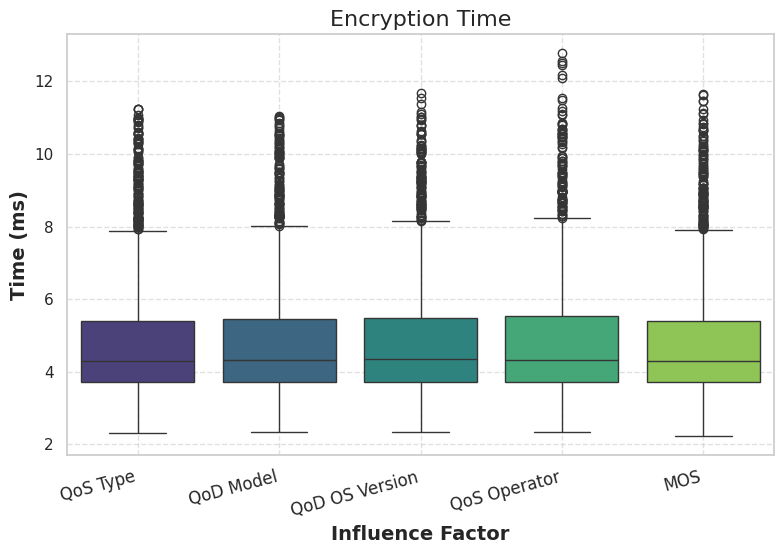

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns
columns = ['QoS_type', 'QoD_model', 'QoD_os-version', 'QoS_operator', 'MOS']
time_columns = [f'{col}_EncryptionTime(ms)' for col in columns]
size_columns = [f'{col}_EncryptedSize(Bytes)' for col in columns]

# Convert data to numeric, ignoring errors for invalid entries like 'Error'
df[time_columns] = df[time_columns].apply(pd.to_numeric, errors='coerce')
df[size_columns] = df[size_columns].apply(pd.to_numeric, errors='coerce')

# Short labels for plots
short_labels = ['QoS Type', 'QoD Model', 'QoD OS Version', 'QoS Operator', 'MOS']

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area
plt.figure(figsize=(8, 6))

# Plot boxplot for encryption times
#plt.subplot(1, 2, 1)
sns.boxplot(data=df[time_columns], palette='viridis')
plt.title('Encryption Time', fontsize=16)
plt.ylabel('Time (ms)', fontsize=14, fontweight='bold')
plt.xlabel('Influence Factor', fontsize=14, fontweight='bold')
plt.xticks(ticks=range(len(time_columns)), labels=short_labels, rotation=15, ha='right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# # Plot boxplot for encrypted sizes
# plt.subplot(1, 2, 2)
# sns.boxplot(data=df[size_columns], palette='viridis')
# plt.title('Encrypted Size Distribution', fontsize=16)
# plt.ylabel('Size (KB)', fontsize=14, fontweight='bold')
# plt.xlabel('Influence Factor', fontsize=14, fontweight='bold')
# plt.xticks(ticks=range(len(size_columns)), labels=short_labels, rotation=15, ha='right', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to avoid overlap and show plots
#plt.suptitle('Encryption Performance Analysis', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("encryption_analysis.pdf", format='pdf')



plt.show()


## Saving the metrics

In [ ]:
import csv


# Calculate statistical information for each column
statistical_data = {}
for col in columns:
    time_col = f'{col}_EncryptionTime(ms)'
    size_col = f'{col}_EncryptedSize(KB)'

    stats = {
        'Encryption Time (ms)': df[time_col].describe(),
        'Encrypted Size (KB)': df[size_col].describe()
    }
    statistical_data[col] = stats

# Save statistical information to a CSV file
output_filename = 'encryption_statistics.csv'
with open(output_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)

    # Write header
    writer.writerow(['Metric', 'Statistic', 'Value'])

    # Write data for each column
    for col, stats in statistical_data.items():
        for metric_type, metric_stats in stats.items():
            for stat_name, stat_value in metric_stats.items():
                writer.writerow([col, f"{metric_type} - {stat_name}", stat_value])

print(f"Statistical information saved to {output_filename}")


KeyError: 'QoS_type_EncryptedSize(KB)'

# New Evaluation (QoE + FHE)

## Local network with all items

In [ ]:
import pandas as pd

# Load the data from the URL
url = "https://github.com/rodrigodg1/privacy-qoe-system/raw/main/fhevm/performance_ITEMS_metrics_client_localhost.csv"
df_local = pd.read_csv(url)


### Transaction Confirmation local


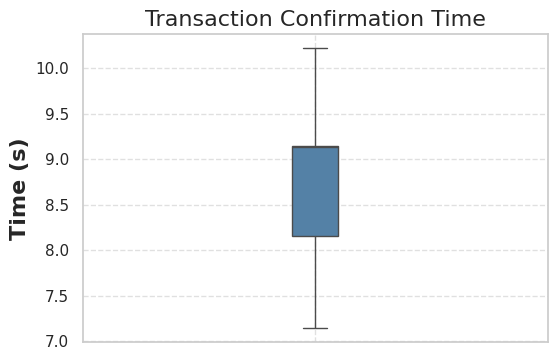

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = df_local

# Function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Convert the 'Transaction Confirmation Time (s)' column to numeric, coercing errors
df['Transaction Confirmation Time (s)'] = pd.to_numeric(df['Transaction Confirmation Time (s)'], errors='coerce')

# Remove outliers from 'Transaction Confirmation Time (s)'
df_transaction_local = remove_outliers(df, 'Transaction Confirmation Time (s)')

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area
plt.figure(figsize=(6, 4))

# Plot boxplot for transaction confirmation time using the cleaned data
sns.boxplot(y=df_transaction_local['Transaction Confirmation Time (s)'], color='steelblue', width=0.1)
plt.title('Transaction Confirmation Time', fontsize=16)
plt.ylabel('Time (s)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot as a PDF
#plt.savefig("transaction_confirmation_time_analysis.pdf", format='pdf')

# Display the plot
plt.show()


### CPU used validator

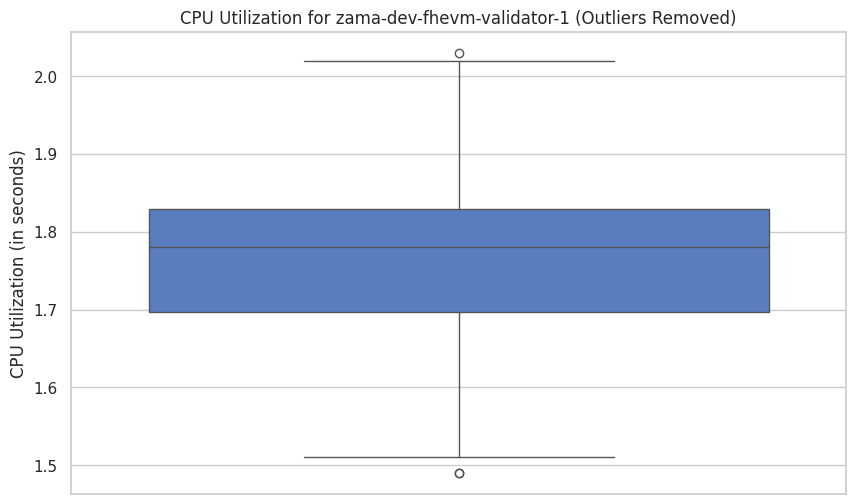

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Load the data from the URL
url = "https://github.com/rodrigodg1/privacy-qoe-system/raw/main/fhevm/cpu_usage_validator.csv"
df_local_validator = pd.read_csv(url)

# Remove outliers
df_local_validator = remove_outliers(df_local_validator, 'zama-dev-fhevm-validator-1')

# Plotting the box plot using Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_local_validator['zama-dev-fhevm-validator-1'])
plt.title('CPU Utilization for zama-dev-fhevm-validator-1 (Outliers Removed)')
plt.ylabel('CPU Utilization (in seconds)')
plt.show()


### Combining into a single plot

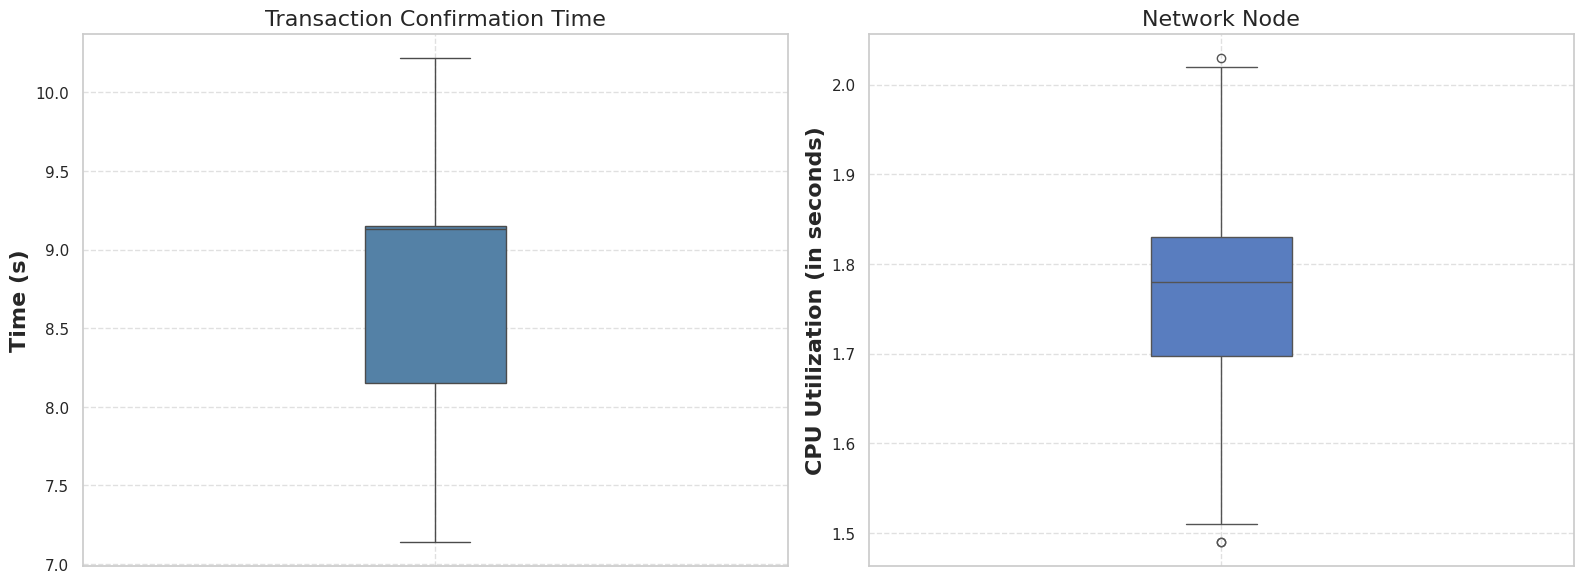

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axis for side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot boxplot for Transaction Confirmation Time on the first axis
sns.boxplot(y=df_transaction_local['Transaction Confirmation Time (s)'], color='steelblue', width=0.2, ax=axes[0])
axes[0].set_title('Transaction Confirmation Time', fontsize=16)
axes[0].set_ylabel('Time (s)', fontsize=16, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot boxplot for CPU Utilization on the second axis
sns.boxplot(y=df_local_validator['zama-dev-fhevm-validator-1'], ax=axes[1], width=0.2)
axes[1].set_title('Network Node', fontsize=16)
axes[1].set_ylabel('CPU Utilization (in seconds)', fontsize=16, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)


confirmation_time_summary = df_transaction_local.describe()
cpu_utilization_summary = df_local_validator.describe()

confirmation_time_summary.to_csv('on_chain_confirmation_time_summary.csv')
cpu_utilization_summary.to_csv('on_chain_cpu_utilization_summary.csv')

plt.savefig("on_chain_analysis.pdf", format='pdf')
# Adjust layout and show the plots
plt.tight_layout()
plt.show()


### Encryption Time (MS), Transaction Size (KB), CPU Usage (ms), Memory Usage (MB)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = df_local  # Ensure that df_local is defined and loaded with data

# Function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Convert data to numeric, ignoring errors for invalid entries
columns_to_process = ['Encryption Time (ms)', 'CPU Usage (ms)', 'Memory Usage (MB)']
for column in columns_to_process:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Remove outliers for each column
for column in columns_to_process:
    df = remove_outliers(df, column)

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area for side-by-side subplots
fig = plt.figure(figsize=(18, 6))

# Plot vertical boxplot for encryption times
ax1 = plt.subplot(1, 3, 1)
sns.boxplot(y=df['Encryption Time (ms)'], color='steelblue', width=0.3)
ax1.set_title('Encryption Time', fontsize=16)
ax1.set_ylabel('Time (ms)', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot vertical boxplot for CPU usage
ax2 = plt.subplot(1, 3, 2)
sns.boxplot(y=df['CPU Usage (ms)'], color='darkorange', width=0.3)
ax2.set_title('CPU Usage', fontsize=16)
ax2.set_ylabel('CPU Usage (ms)', fontsize=16, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot vertical boxplot for memory usage
ax3 = plt.subplot(1, 3, 3)
sns.boxplot(y=df['Memory Usage (MB)'], color='seagreen', width=0.3)
ax3.set_title('Memory Usage', fontsize=16)
ax3.set_ylabel('Memory Usage (MB)', fontsize=16, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

# Add a single x-axis label
fig.text(0.5, 0.04, 'Encryption Performance Across All Selected QoE Factors: QoS Type, QoD Model, QoD OS Version, QoS Operator, and MOS.', ha='center', va='center', fontsize=16, fontweight='bold')

# Adjust layout to avoid overlap and show plots
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save the plot as a PDF
plt.savefig("encryption_performance_analysis.pdf", format='pdf')

# Display the plot
plt.show()

# Print summary statistics for each column after outlier removal
for column in columns_to_process:
    print(f"\nSummary statistics for {column}:")
    print(df[column].describe())


## Testnet with all items

In [ ]:
import pandas as pd

# Load the data from the URL
url = "https://github.com/rodrigodg1/privacy-qoe-system/raw/main/fhevm/performance_ITEMS_metrics_client_devnet.zama.ai.csv"
df_testnet = pd.read_csv(url)


### Encryption Time (MS), Transaction Size (KB), CPU Usage (%), Memory Usage (MB)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = df_testnet

# Function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Convert data to numeric, ignoring errors for invalid entries
columns_to_process = ['Encryption Time (ms)', 'CPU Usage (ms)', 'Memory Usage (MB)']
for column in columns_to_process:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Remove outliers for each column
for column in columns_to_process:
    df = remove_outliers(df, column)

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area for side-by-side subplots
plt.figure(figsize=(18, 6))  # Adjusted for better spacing

# Plot vertical boxplot for encryption times
plt.subplot(1, 3, 1)  # 1 row, 3 columns, 1st subplot
sns.boxplot(y=df['Encryption Time (ms)'], color='steelblue', width=0.5)
plt.title('Encryption Time', fontsize=16)
plt.ylabel('Time (ms)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot vertical boxplot for CPU usage
plt.subplot(1, 3, 2)  # 1 row, 3 columns, 2nd subplot
sns.boxplot(y=df['CPU Usage (ms)'], color='darkorange', width=0.5)
plt.title('CPU Usage', fontsize=16)
plt.ylabel('CPU Usage (ms)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot vertical boxplot for memory usage
plt.subplot(1, 3, 3)  # 1 row, 3 columns, 3rd subplot
sns.boxplot(y=df['Memory Usage (MB)'], color='seagreen', width=0.5)
plt.title('Memory Usage', fontsize=16)
plt.ylabel('Memory Usage (MB)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to avoid overlap and show plots
plt.tight_layout()

# Save the plot as a PDF
plt.savefig("encryption_performance_analysis_without_outliers.pdf", format='pdf')

# Display the plot
plt.show()

# Print summary statistics for each column after outlier removal
for column in columns_to_process:
    print(f"\nSummary statistics for {column}:")
    print(df[column].describe())


### Transaction Confirmation testnet


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Convert the 'Transaction Confirmation Time (s)' column to numeric, coercing errors
df['Transaction Confirmation Time (s)'] = pd.to_numeric(df['Transaction Confirmation Time (s)'], errors='coerce')

# Remove outliers from 'Transaction Confirmation Time (s)'
df_cleaned = remove_outliers(df, 'Transaction Confirmation Time (s)')

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area
plt.figure(figsize=(10, 6))

# Plot boxplot for transaction confirmation time using the cleaned data
sns.boxplot(y=df_cleaned['Transaction Confirmation Time (s)'], color='gold', width=0.3)
plt.title('Transaction Confirmation Time Distribution', fontsize=16)
plt.ylabel('Time (s)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot as a PDF
plt.savefig("transaction_confirmation_time_analysis.pdf", format='pdf')

# Display the plot
plt.show()


## Comparsion Confirmation time

In [ ]:
# prompt: create a boxplo to compare df_local["Transaction Confirmation Time (s)"] with df_testnet["Transaction Confirmation Time (s)"]

# Combine the dataframes
df_combined = pd.concat([
    df_local['Transaction Confirmation Time (s)'].rename('Local'),
    df_testnet['Transaction Confirmation Time (s)'].rename('Testnet')
], axis=1)

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Set up the plotting area
plt.figure(figsize=(10, 6))

# Plot boxplot for comparison
sns.boxplot(data=df_combined, width=0.4)
plt.title('Transaction Confirmation Time Comparison', fontsize=16)
plt.ylabel('Time (s)', fontsize=14, fontweight='bold')
plt.xlabel('Network', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot as a PDF
plt.savefig("transaction_confirmation_time_comparison.pdf", format='pdf')

# Display the plot
plt.show()
